**IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("P653_pronostico_dataset.csv", sep=";")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [ ]:
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [ ]:
df.tail()


,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
5995,5995,49.611850,94.857639,86.615671,107.643986,no_retinopathy
5996,5996,63.099686,100.039527,93.515186,104.971404,retinopathy
5997,5997,55.562243,98.421446,102.697875,120.875951,retinopathy
5998,5998,63.468956,106.809289,88.060631,106.052213,retinopathy
5999,5999,62.506825,96.900784,86.878033,108.625436,no_retinopathy


In [ ]:
df.describe()

,ID,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2999.500000,60.464121,100.694822,90.505547,100.628255
std,1732.195139,8.564392,10.669267,9.648200,10.433915
min,0.000000,35.164761,69.675429,62.807105,69.967453
25%,1499.750000,54.371941,93.267420,83.641788,93.202373
50%,2999.500000,59.831159,100.119926,89.912429,100.060637
75%,4499.250000,65.809652,107.439501,96.682405,107.250829
max,5999.000000,103.279497,151.699660,133.456382,148.233544


**DATA CLEANING AND PREPARATION**

In [ ]:
df.isnull().sum()


,0
ID,0
age,0
systolic_bp,0
diastolic_bp,0
cholesterol,0
prognosis,0


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
le = LabelEncoder()
df["prognosis"] = le.fit_transform(df["prognosis"]) # converts categorical values in (prognosis) column into numerical values    #ML Models working method

In [ ]:
le.classes_

array(['no_retinopathy', 'retinopathy'], dtype=object)

In [ ]:
df.head() # FINAL CLEAN DATASET

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,1
1,1,63.529850,99.379736,84.852361,110.382411,1
2,2,69.003986,111.349455,109.850616,100.828246,1
3,3,82.638210,95.056128,79.666851,87.066303,1
4,4,78.346286,109.154591,90.713220,92.511770,1


**EXPLORATORY DATA ANALYSIS(EDA)**

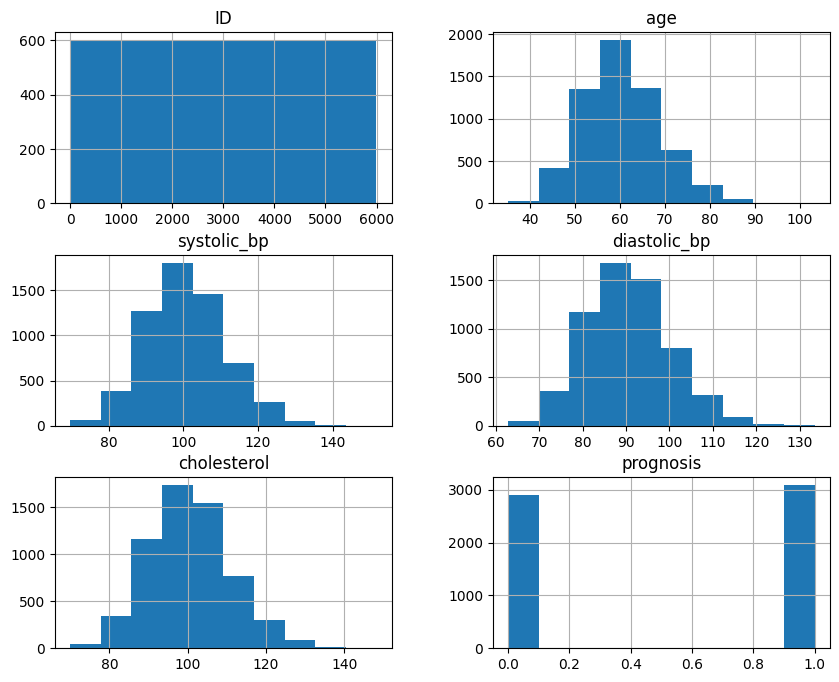

In [ ]:
#HISTOGRAM
df.hist(figsize=(10,8))
plt.show()

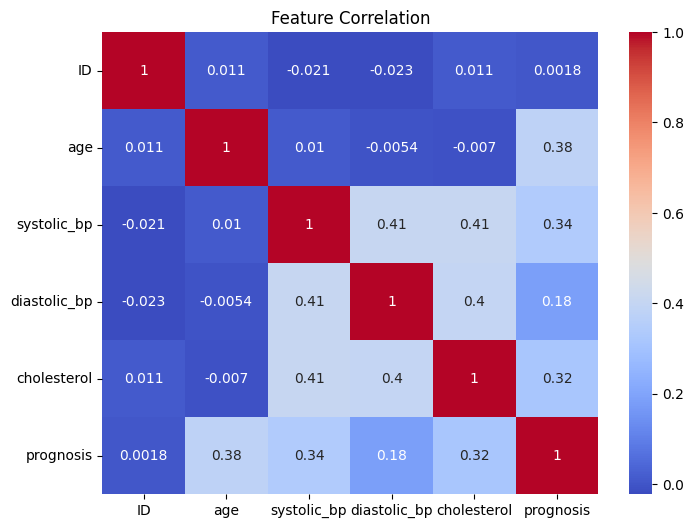

In [ ]:
#CORREALATION HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

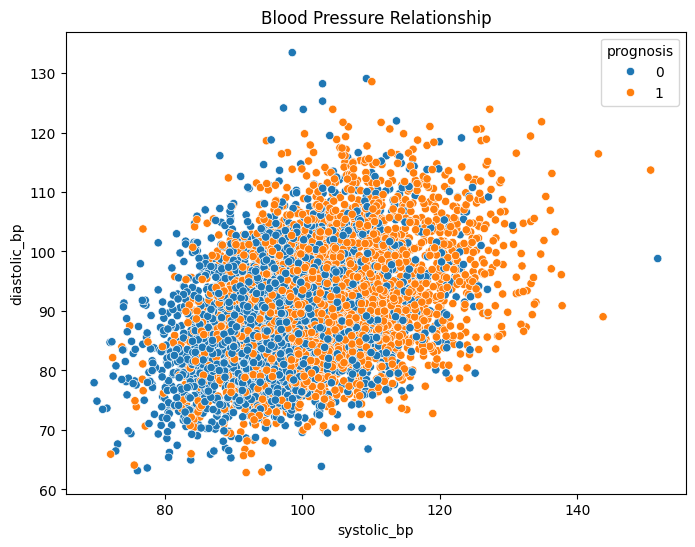

In [ ]:
#SCATTER PLOT
plt.figure(figsize=(8,6))
sns.scatterplot(x="systolic_bp", y="diastolic_bp", hue="prognosis", data=df)
plt.title("Blood Pressure Relationship")
plt.show()

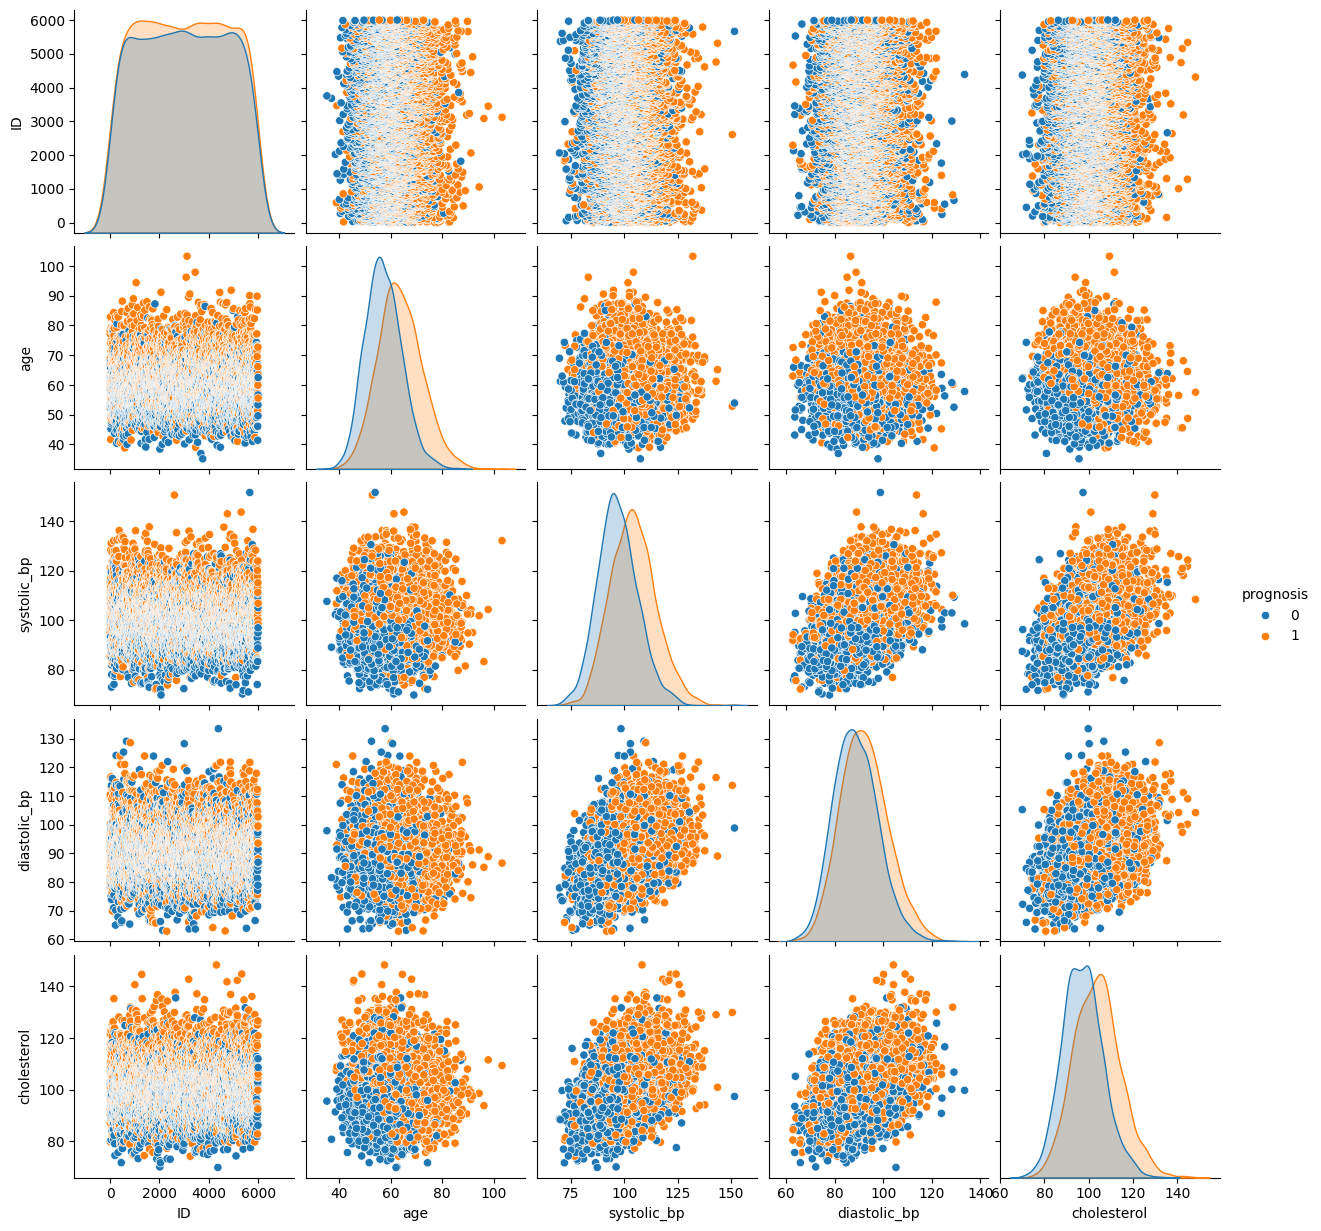

In [ ]:
sns.pairplot(
    df,
    hue="prognosis",
    diag_kind="kde"
)

plt.show()

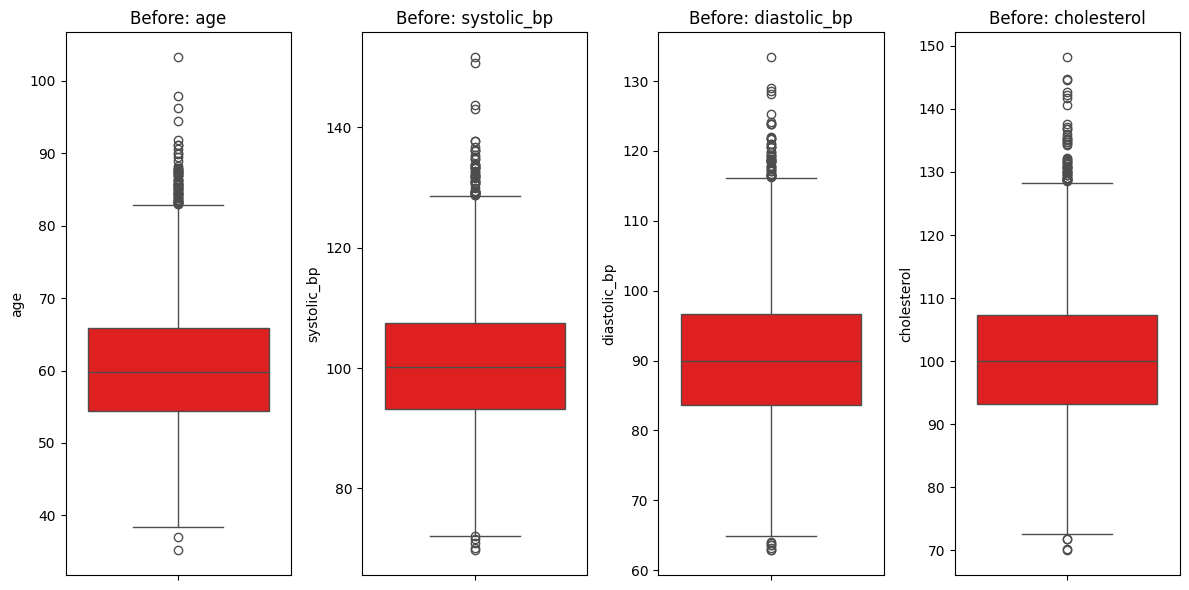

In [ ]:
#BOX PLOT (BEFORE REMOVAL OF OUTLIERS)
plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df[col], color="red")
    plt.title(f"Before: {col}")

plt.tight_layout()
plt.show()

HERE , WE GOT THE OUTLIERS FOR THE BOX PLOT IN THE GIVEN DATA SET.
TO DETECT THESE OUTLIERS , WE USE THE IQR METHOD

**DETECTING OUTLIERS USING INTER QUARTILE RANGE (IQR) METHOD**

In [ ]:
#MAIN METHOD OF IQR
df_clean = df.copy()

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

In [ ]:
for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col} : {len(outliers)} outliers")

age : 65 outliers
systolic_bp : 55 outliers
diastolic_bp : 55 outliers
cholesterol : 54 outliers


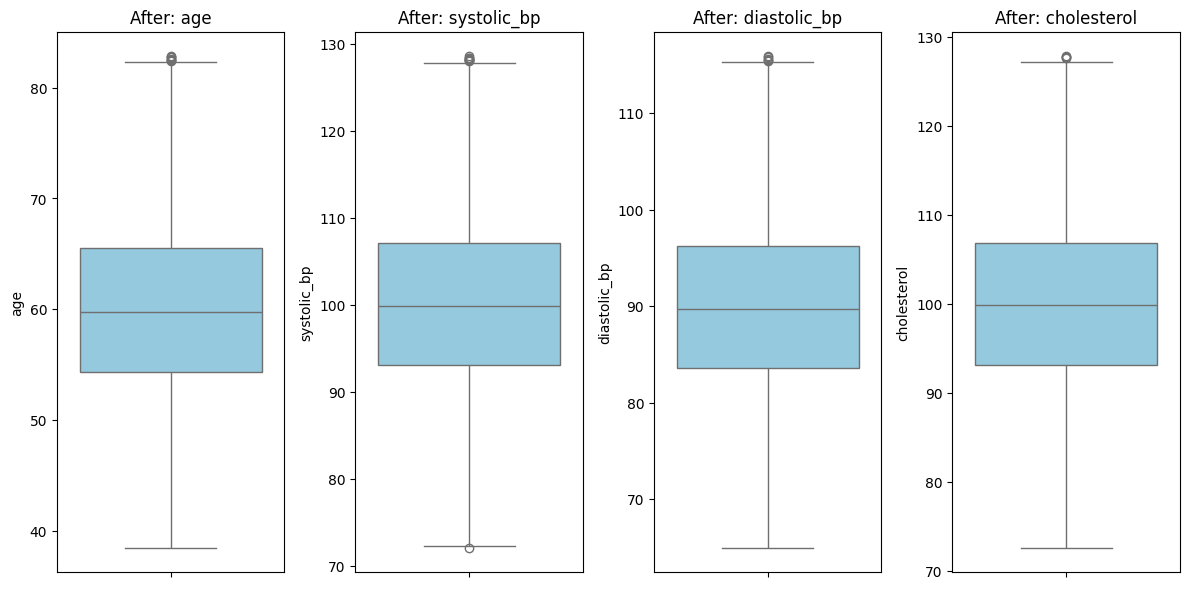

In [ ]:
#BOX PLOT (AFTER REMOVAL OF OUTLIERS)
plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df_clean[col], color="skyblue")
    plt.title(f"After: {col}")

plt.tight_layout()
plt.show()

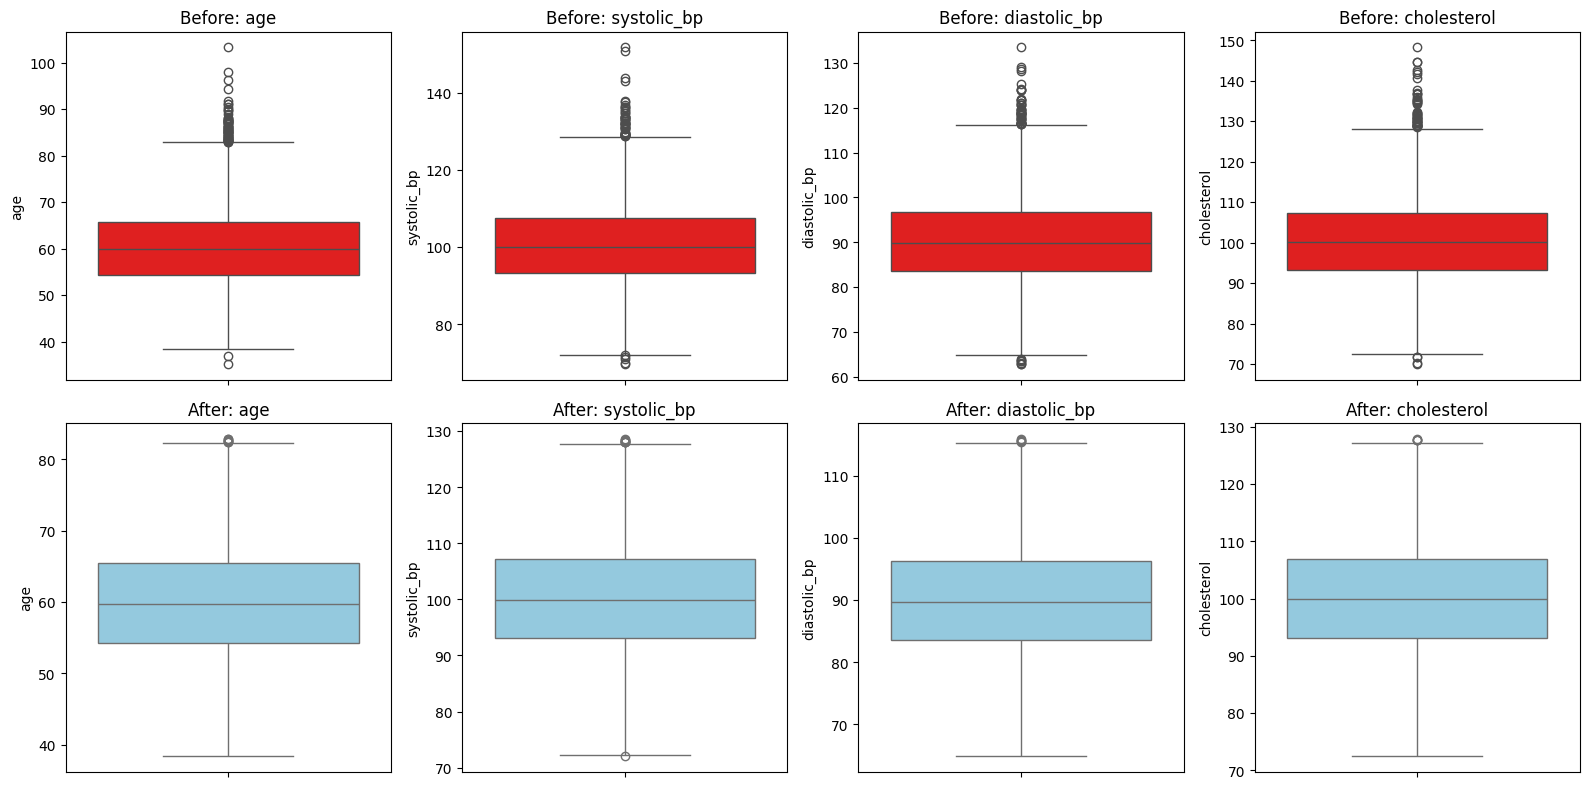

In [ ]:
#comparision of before and after removal of outliers for box plot
fig, axes = plt.subplots(2,4, figsize=(16,8))

for i, col in enumerate(num_cols):

    sns.boxplot(y=df[col], ax=axes[0,i], color="red")
    axes[0,i].set_title(f"Before: {col}")

    sns.boxplot(y=df_clean[col], ax=axes[1,i], color="skyblue")
    axes[1,i].set_title(f"After: {col}")

plt.tight_layout()
plt.show()

In [ ]:
print(df_clean.shape)

(5777, 6)
